### Lunar Craters (Algolymp PreOJIA XI-XII)
---
[Task Link](https://judge.nitro-ai.org/competitions/algolymp/algolymp-preojia-xi-xii/1/view)

In [480]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

In [481]:
train_ds = pd.read_csv("data/train_data.csv")
test_ds = pd.read_csv("data/test_data.csv")

In [482]:
def load_ds(ds):
    images = []
    for id in ds['id']:
        filename = f"data/images/{str(id).zfill(4)}.png"
        img = Image.open(filename)
        images.append(img)
    print("Loaded: ", len(images), " images")
    ds.insert(0, "image", images)
    return ds


In [483]:
train_ds = load_ds(train_ds)
test_ds = load_ds(test_ds)

Loaded:  700  images
Loaded:  300  images


[[198 191 185 ... 127 135 131]
 [212 204 195 ... 150 147 129]
 [216 202 209 ... 180 168 133]
 ...
 [105 115 144 ... 210 197 170]
 [110 111 124 ... 209 205 195]
 [114 116 126 ... 196 198 195]]


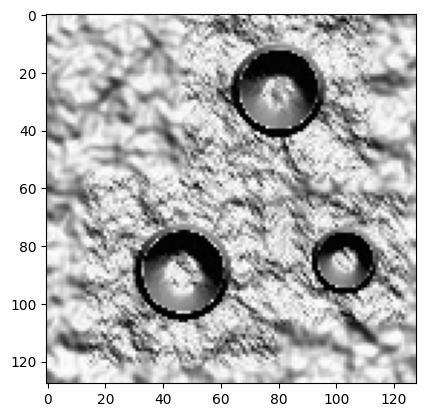

In [484]:
plt.imshow(train_ds['image'][2], cmap='gray')
print(np.array(train_ds['image'][2]))

In [485]:
def count_craters(img, min_shape=20, debug=False):
    img = np.array(img)

    blurred = cv2.medianBlur(img, ksize=7)

    _, thresh = cv2.threshold(blurred, thresh=50, maxval=255, type=cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    if debug:
        plt.imshow(img, cmap='gray')
        plt.show()
        plt.imshow(blurred, cmap='gray')
        plt.show()
        plt.imshow(thresh, cmap='gray')
        plt.show()

    cnt = 0

    for contour in contours:
        if contour.shape[0] > min_shape:
            cnt += 1
    return np.clip(cnt, 3, 8)

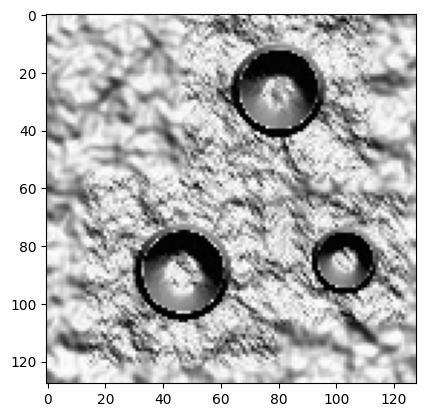

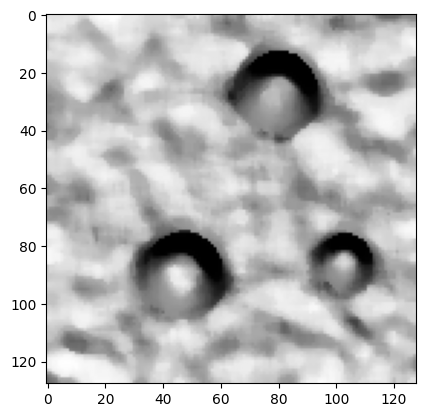

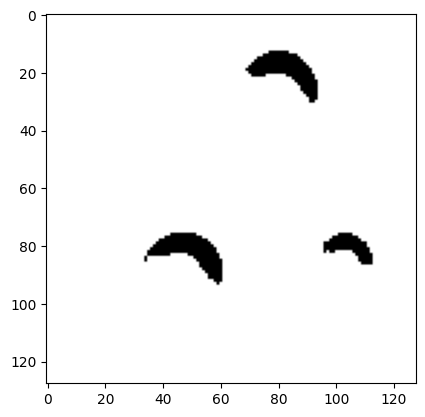

3


In [486]:
print(count_craters(train_ds['image'][2], debug=True))

In [487]:
answ = []

for img in test_ds['image']:
    answ.append(count_craters(img))

subtask1 = pd.DataFrame({
    "subtaskID": 1,
    "datapointID": test_ds['id'],
    "answer": answ,
})

subtask1

,subtaskID,datapointID,answer
0,1,700,4
1,1,701,4
2,1,702,3
3,1,703,6
4,1,704,3
...,...,...,...
295,1,995,3
296,1,996,4
297,1,997,3
298,1,998,5


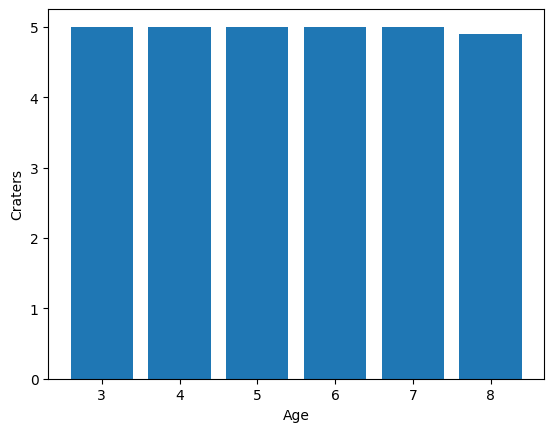

In [488]:
plt.bar(train_ds['count'], train_ds['age'])
plt.xlabel("Age")
plt.ylabel("Craters")
plt.show()

In [489]:
from torchvision import transforms

transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

In [490]:
class CraterTrainDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = row["image"]
        age = torch.tensor(row["age"], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "age": age
        }

In [491]:
class CreateTestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = row["image"]

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
        }

In [492]:
train_split, val_split = train_test_split(train_ds, test_size=0.2, random_state=42)

train_dataset = CraterTrainDataset(train_split, transform=transforms)
val_dataset = CraterTrainDataset(val_split, transform=transforms)


In [493]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [494]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> 16 channels
        x = self.pool(F.relu(self.conv2(x)))   # -> 32 channels
        x = self.pool(F.relu(self.conv3(x)))   # -> 64 channels
        x = self.pool(F.relu(self.conv4(x)))   # -> 128 channels

        x = self.gap(x)                        # -> [B, 128, 1, 1]
        x = torch.flatten(x, 1)                # -> [B, 128]

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [495]:
num_epochs = 200
learning_rate = 1e-4
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [496]:
def validation(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_mse = 0.0
    total_mae = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(device)
            labels = batch["age"].float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            total_samples += batch_size

            total_loss += loss.item() * batch_size
            total_mse += torch.sum((outputs - labels) ** 2).item()
            total_mae += torch.sum(torch.abs(outputs - labels)).item()

    avg_loss = total_loss / total_samples
    avg_mse = total_mse / total_samples
    avg_mae = total_mae / total_samples
    avg_rmse = avg_mse ** 0.5

    print(f"Validation | Loss: {avg_loss:.4f} | MSE: {avg_mse:.4f} | RMSE: {avg_rmse:.4f} | MAE: {avg_mae:.4f}")

    return avg_loss, avg_mse, avg_rmse, avg_mae

In [497]:
train_mae_history = []
val_mae_history = []

train_loss_history = []
val_loss_history = []

best_val_loss = float("inf")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total_mse = 0.0
    total_mae = 0.0
    total_samples = 0

    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["age"].float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        total_samples += batch_size

        total_loss += loss.item() * batch_size

        with torch.no_grad():
            total_mse += torch.sum((outputs - labels) ** 2).item()
            total_mae += torch.sum(torch.abs(outputs - labels)).item()

    avg_train_loss = total_loss / total_samples
    avg_train_mse = total_mse / total_samples
    avg_train_mae = total_mae / total_samples
    avg_train_rmse = avg_train_mse ** 0.5

    train_loss_history.append(avg_train_loss)
    train_mae_history.append(avg_train_mae)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train MSE: {avg_train_mse:.4f} | "
        f"Train RMSE: {avg_train_rmse:.4f} | "
        f"Train MAE: {avg_train_mae:.4f}"
    )

    val_loss, val_mse, val_rmse, val_mae = validation(model, val_loader, criterion, device)

    val_loss_history.append(val_loss)
    val_mae_history.append(val_mae)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "models/best_age_model.pth")
        print("✅ Saved best model")

Epoch 1/200 | Train Loss: 9.9715 | Train MSE: 9.9715 | Train RMSE: 3.1578 | Train MAE: 2.9523
Validation | Loss: 7.8148 | MSE: 7.8148 | RMSE: 2.7955 | MAE: 2.5853
✅ Saved best model
Epoch 2/200 | Train Loss: 7.1343 | Train MSE: 7.1343 | Train RMSE: 2.6710 | Train MAE: 2.4191
Validation | Loss: 3.2734 | MSE: 3.2734 | RMSE: 1.8092 | MAE: 1.5276
✅ Saved best model
Epoch 3/200 | Train Loss: 1.8811 | Train MSE: 1.8811 | Train RMSE: 1.3715 | Train MAE: 1.1067
Validation | Loss: 1.2179 | MSE: 1.2179 | RMSE: 1.1036 | MAE: 0.9538
✅ Saved best model
Epoch 4/200 | Train Loss: 1.1708 | Train MSE: 1.1708 | Train RMSE: 1.0820 | Train MAE: 0.8983
Validation | Loss: 0.7335 | MSE: 0.7335 | RMSE: 0.8565 | MAE: 0.6952
✅ Saved best model
Epoch 5/200 | Train Loss: 1.1496 | Train MSE: 1.1496 | Train RMSE: 1.0722 | Train MAE: 0.8823
Validation | Loss: 0.6963 | MSE: 0.6963 | RMSE: 0.8344 | MAE: 0.7027
✅ Saved best model
Epoch 6/200 | Train Loss: 0.9862 | Train MSE: 0.9862 | Train RMSE: 0.9931 | Train MAE: 0.8

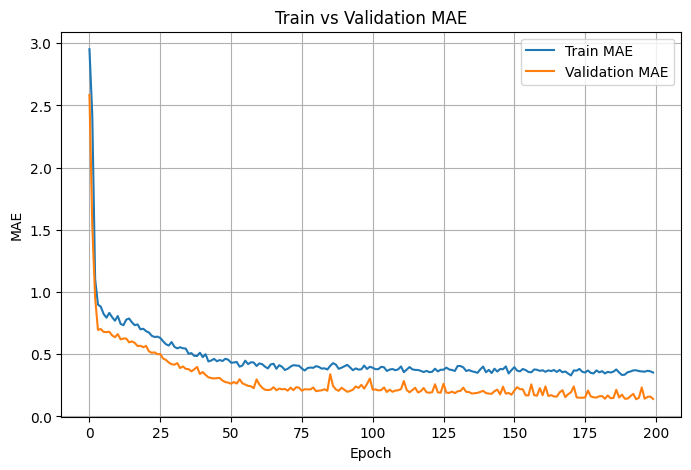

In [498]:
plt.figure(figsize=(8, 5))
plt.plot(train_mae_history, label="Train MAE")
plt.plot(val_mae_history, label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Train vs Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

In [499]:
model.load_state_dict(torch.load("models/best_age_model.pth"))

model.eval()
test_dataset = CreateTestDataset(test_ds, transform=transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [500]:
preds = []

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        output = model(images)
        preds.append(output.cpu())

preds = torch.cat(preds, dim=0)
preds_list = preds.squeeze().tolist()

In [501]:
subtask2 = pd.DataFrame({
    "subtaskID": 2,
    "datapointID": test_ds['id'],
    "answer": preds_list,
})


subtask2

,subtaskID,datapointID,answer
0,2,700,2.502620
1,2,701,1.319504
2,2,702,4.499054
3,2,703,3.404540
4,2,704,2.566144
...,...,...,...
295,2,995,1.582698
296,2,996,2.185434
297,2,997,2.438938
298,2,998,1.130202


In [502]:
result = pd.concat([subtask1, subtask2], axis=0)
result.to_csv("result.csv", index=False)

### Note: Ignore this cell. This is to organize projects in the README.MD
```json
{
"Tags": ["Regression", "CNN", "Computer Vision"]
}
```